<a href="https://colab.research.google.com/github/Mattmflores/ADTA_Group_8/blob/main/period-and-revolution-time-rigid-pendulum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import math, numpy as np
from scipy.integrate import solve_ivp

## **Extract T and $T_{\text{rev}}$ versus the initial angular velocity (`ang_vel_0`)**

In [20]:
# Constants
I = 1.0
omega0 = 1.0
theta0 = 0.0
Vmax = I*omega0**2*(1 - math.cos(math.pi))  # = 2 I ω0²

##Functions | **rhs** and **energy**

Differential equations governing the nonlinear pendulum and its total energy.

Defines the right-hand side (RHS) of the pendulum’s equation of motion.

The rigid pendulum is described by the second-order ODE:

$$
\ddot{\theta} = -\omega_0^2 \sin(\theta)
$$


Solve by converting it into two first-order equations:

\
\begin{cases}
\frac{d\theta}{dt} = \dot{\theta} \\
\frac{d\dot{\theta}}{dt} = -\omega_0^2 \sin(\theta)
\end{cases}


The function returns these derivatives as a list:


In [21]:
# Defines motion equations
def rhs(t, y):
    theta, theta_dot = y
    return [theta_dot, -omega0**2*math.sin(theta)]

In [22]:
# Computes total energy
def energy(theta, theta_dot):
    return 0.5*I*theta_dot**2 + I*omega0**2*(1 - math.cos(theta))

###Events

In [23]:
# event: θ̇ = 0 with negative crossing -> maxima of θ
def maxima_event(t, y):
    return y[1]

In [24]:
# event: θ − θ0 − 2π = 0 (first full revolution)
def make_revolution_event(theta0):
    def revolution_event(t, y):
        return y[0] - theta0 - 2*math.pi

    revolution_event.direction = +1
    revolution_event.terminal = True

    return revolution_event

In [25]:
maxima_event.direction = -1 # detect only decreasing crossings
maxima_event.terminal = False # more than one event (two consecutive maxima) to measure a period

### Using Events to Find Period and Revolution Time

In [26]:
# calculates the pendulum’s period (T)
def period_via_events(ang_vel_0, tmax=50.0):
    sol = solve_ivp(
        rhs,
        [0, tmax],
        [theta0,
        ang_vel_0],
        rtol=1e-9,
        atol=1e-12,
        events=[maxima_event],
        max_step=0.02
      )

    peaks = sol.t_events[0] if sol.t_events else []

    if len(peaks) >= 2:
        return peaks[1] - peaks[0]

    return float('nan')

In [27]:
# calculates the revolution time
def revolution_time_via_event(ang_vel_0, tmax=50.0):
    if energy(theta0, ang_vel_0) <= Vmax:
        return float('nan')

    rev_event = make_revolution_event(theta0)
    sol = solve_ivp(
        rhs,
        [0, tmax],
        [theta0,
         ang_vel_0],
        rtol=1e-9,
        atol=1e-12,
        events=[rev_event],
        max_step=0.02
    )

    if sol.t_events and len(sol.t_events[0]) >= 1:
        return sol.t_events[0][0]

    return float('nan')

### Sweeping Over Initial Angular Velocity

Sweep the initial angular velocity `ang_vel_0` to see how the period **T** (oscillation)
and the revolution time $T_{\text{rev}}$ change.



In [28]:
# sweep over ang_vel_0
v_vals = np.linspace(0.0, 6.0, 61)
T_event   = np.array([period_via_events(v)         for v in v_vals])
Trev_event= np.array([revolution_time_via_event(v) for v in v_vals])


## **Define and solve (numerically) the integral form for T and $T_{\text{rev}}$**


In [29]:
from scipy.integrate import quad

In [30]:
# integral - calculates the pendulum’s period (T)
def period_via_integral(ang_vel_0, theta0=0.0):
    E = energy(theta0, ang_vel_0)

    if E >= Vmax:
        return float('nan')

    val = max(0.0, min(2.0, E/(I*omega0**2)))
    theta_max = math.acos(1 - val)

    def integrand(th):
        denom = 2*(E - V(th))/I
        return 1.0 / math.sqrt(max(denom, 1e-30))

    integral, _ = quad(
        integrand,
        0.0,
        theta_max,
        limit=200,
        epsabs=1e-10,
        epsrel=1e-10
        )

    return 4*integral

In [31]:
# integral - calculates the revolution time
def revolution_via_integral(ang_vel_0, theta0=0.0):
    E = energy(theta0, ang_vel_0)

    if E <= Vmax:
        return float('nan')

    def integrand(th):
        denom = 2*(E - V(th))/I
        return 1.0 / math.sqrt(max(denom, 1e-30))

    integral, _ = quad(
        integrand,
        0.0,
        2*math.pi,
        limit=400,
        epsabs=1e-10,
        epsrel=1e-10
        )

    return integral

In [32]:
# sweep over ang_vel_0
T_integral    = np.array([period_via_integral(v, theta0)      for v in v_vals])
Trev_integral = np.array([revolution_via_integral(v, theta0)  for v in v_vals])


### **Plot these two results together in a labeled figure**

In [33]:
import matplotlib.pyplot as plt

In [42]:
# Masks to avoid drawing lines through NaNs
m_T_evt   = ~np.isnan(T_event) # valid period event data
m_T_int   = ~np.isnan(T_integral) # valid period integral data
m_Tr_evt  = ~np.isnan(Trev_event) # valid revolution event data
m_Tr_int  = ~np.isnan(Trev_integral) # valid revolution integral data

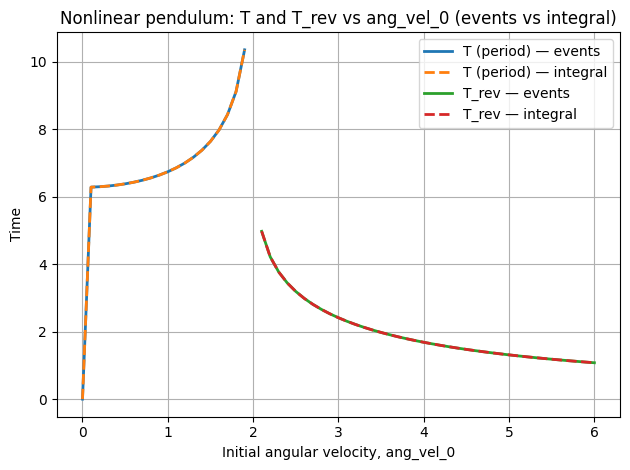

In [43]:
# T (period)
plt.plot(v_vals[m_T_evt],  T_event[m_T_evt],  label="T (period) — events",  linewidth=2)
plt.plot(v_vals[m_T_int],  T_integral[m_T_int],  linestyle="--", label="T (period) — integral", linewidth=2)

# T_rev (revolution)
plt.plot(v_vals[m_Tr_evt], Trev_event[m_Tr_evt], label="T_rev — events",  linewidth=2)
plt.plot(v_vals[m_Tr_int], Trev_integral[m_Tr_int], linestyle="--", label="T_rev — integral", linewidth=2)

# Legend & Labels
plt.xlabel("Initial angular velocity, ang_vel_0")
plt.ylabel("Time")
plt.title("Nonlinear pendulum: T and T_rev vs ang_vel_0 (events vs integral)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
